In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest

from sklearn.metrics import classification_report,confusion_matrix,precision_score,f1_score

In [3]:
df=pd.read_csv('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [5]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Class distribution:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


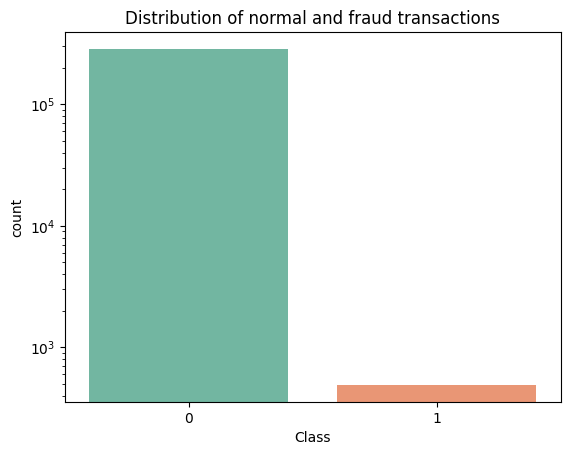

In [6]:
print('Class distribution:')
print(df['Class'].value_counts(normalize=True)*100)

sns.countplot(x='Class',data=df,hue='Class',palette='Set2',legend=False)
plt.title('Distribution of normal and fraud transactions')
plt.yscale('log')
plt.show()

In [7]:
scaler=RobustScaler()
df['scaled_amount']=scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time']=scaler.fit_transform(df['Time'].values.reshape(-1,1))

X=df.drop('Class',axis=1)
y=df['Class']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [8]:
print('The amount of fraud transactions before SMOTE in train:',sum(y_train==1))

smote=SMOTE(random_state=42)
X_train_smote,y_train_smote=smote.fit_resample(X_train,y_train)

print('The amount of fraud transactions after SMOTE in train:',sum(y_train_smote==1))
print('The amount of normal transactions after SMOTE in train:',sum(y_train_smote==0))

The amount of fraud transactions before SMOTE in train: 394
The amount of fraud transactions after SMOTE in train: 227451
The amount of normal transactions after SMOTE in train: 227451


In [9]:
log_reg=LogisticRegression(max_iter=2000,solver='saga',random_state=42)
log_reg.fit(X_train_smote,y_train_smote)
log_pred=log_reg.predict(X_test)

rf_clf=RandomForestClassifier(n_estimators=20,max_depth=5,random_state=42,n_jobs=-1)
rf_clf.fit(X_train_smote,y_train_smote)
rf_pred=rf_clf.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


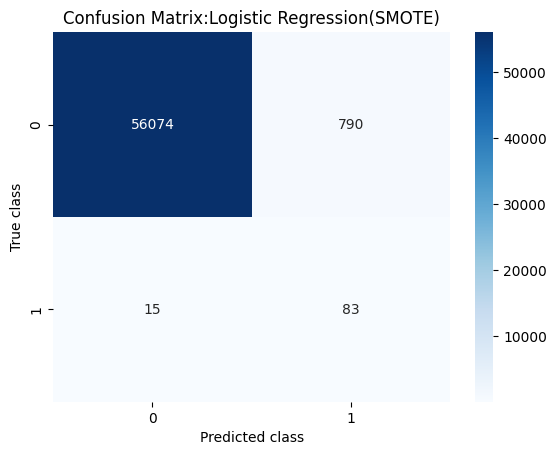

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.10      0.85      0.17        98

    accuracy                           0.99     56962
   macro avg       0.55      0.92      0.58     56962
weighted avg       1.00      0.99      0.99     56962



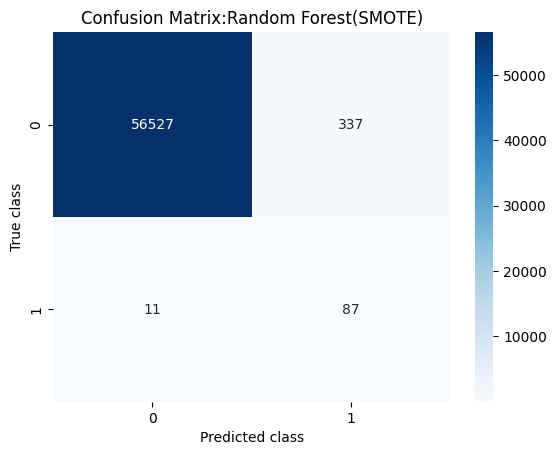

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.21      0.89      0.33        98

    accuracy                           0.99     56962
   macro avg       0.60      0.94      0.67     56962
weighted avg       1.00      0.99      1.00     56962



In [10]:
def plot_matrix(y_true,y_pred,title):
    cm=confusion_matrix(y_true,y_pred)
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
    plt.title(title)
    plt.ylabel('True class')
    plt.xlabel('Predicted class')
    plt.show()
    print(classification_report(y_true,y_pred))
plot_matrix(y_test,log_pred,'Confusion Matrix:Logistic Regression(SMOTE)')
plot_matrix(y_test,rf_pred,'Confusion Matrix:Random Forest(SMOTE)')

Results Isolation Forest(unsupervised learning):


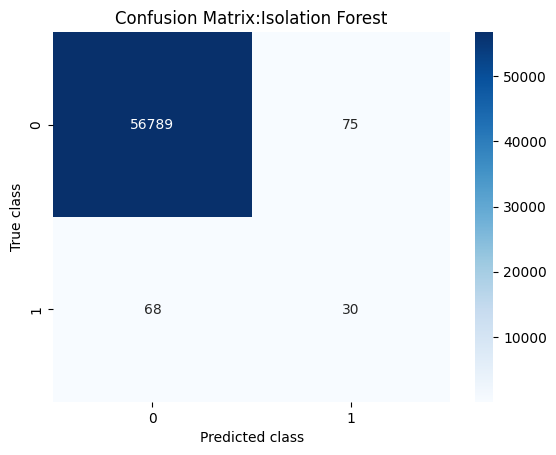

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.29      0.31      0.30        98

    accuracy                           1.00     56962
   macro avg       0.64      0.65      0.65     56962
weighted avg       1.00      1.00      1.00     56962



In [11]:
iso_forest=IsolationForest(n_estimators=100,contamination=0.0017,random_state=42)
iso_forest.fit(X_train)

iso_preds=iso_forest.predict(X_test)

iso_preds_mapped=np.where(iso_preds==1,0,1)

print('Results Isolation Forest(unsupervised learning):')
plot_matrix(y_test,iso_preds_mapped,'Confusion Matrix:Isolation Forest')

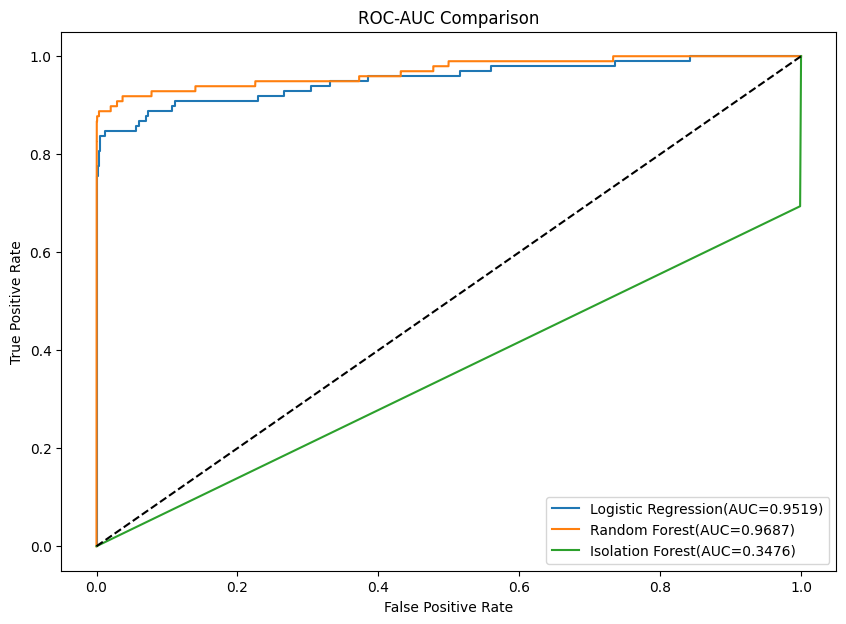

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score

def plot_roc_curves(models,X_test,y_test):
    plt.figure(figsize=(10,7))

    for name,model in models.items():
        if hasattr(model,'predict_proba'):
            probs=model.predict_proba(X_test)[:,1]
        else:
            probs=model.predict(X_test).flatten()

        fpr,tpr,_=roc_curve(y_test,probs)
        auc=roc_auc_score(y_test,probs)

        plt.plot(fpr,tpr,label=f'{name}(AUC={auc:.4f})')

    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-AUC Comparison')
    plt.legend()
    plt.show()
models_dict = {'Logistic Regression': log_reg, 'Random Forest': rf_clf,'Isolation Forest':iso_forest}
plot_roc_curves(models_dict, X_test, y_test)

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout

model_nn=Sequential([
    Dense(32,activation='relu',input_shape=(X_train_smote.shape[1],)),
    Dropout(0.2),
    Dense(16,activation='relu'),
    Dense(1,activation='sigmoid')
])

model_nn.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy',tf.keras.metrics.AUC(name='auc')])

history=model_nn.fit(
    X_train_smote,y_train_smote,
    validation_split=0.2,
    batch_size=32,
    epochs=20,
    verbose=1
)

nn_probs=model_nn.predict(X_test).flatten()
nn_preds=(nn_probs>0.5).astype(int)

2026-04-17 06:30:28.263619: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776407428.491039      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776407428.558301      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776407429.138073      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776407429.138113      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776407429.138117      55 computation_placer.cc:177] computation placer alr

Epoch 1/20
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step - accuracy: 0.5748 - auc: 0.5279 - loss: 113.2165 - val_accuracy: 0.0148 - val_auc: 0.0000e+00 - val_loss: 0.9645
Epoch 2/20
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - accuracy: 0.6400 - auc: 0.5269 - loss: 0.6555 - val_accuracy: 0.0968 - val_auc: 0.0000e+00 - val_loss: 0.9292
Epoch 3/20
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - accuracy: 0.6705 - auc: 0.5672 - loss: 0.6179 - val_accuracy: 0.1434 - val_auc: 0.0000e+00 - val_loss: 0.9176
Epoch 4/20
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - accuracy: 0.6892 - auc: 0.5993 - loss: 0.5958 - val_accuracy: 0.9397 - val_auc: 0.0000e+00 - val_loss: 0.1037
Epoch 5/20
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - accuracy: 0.8711 - auc: 0.8510 - loss: 0.3480 - val_accuracy: 0.9896 - val_auc: 0.0000e+00 - val_loss: 0.0244
Epoch 6/20
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - accuracy: 0.8718 - auc: 0.8504 - loss: 0.3465 - val_accuracy: 0.4967 - val_auc: 0.0000e+00 - v

In [18]:
from sklearn.utils import shuffle

X_train_smote,y_train_smote=shuffle(X_train_smote,y_train_smote,random_state=42)

model_nn=Sequential([
    tf.keras.layers.Input(shape=(X_train_smote.shape[1],)),
    Dense(32,activation='relu'),
    Dropout(0.3),
    Dense(16,activation='relu'),
    Dense(1,activation='sigmoid')
])

model_nn.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy',tf.keras.metrics.AUC(name='auc')])

history=model_nn.fit(
    X_train_smote,y_train_smote,
    validation_split=0.2,
    batch_size=2048,
    epochs=10,
    verbose=1
)

Epoch 1/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5004 - auc: 0.5004 - loss: 3322.0168 - val_accuracy: 0.4986 - val_auc: 0.4952 - val_loss: 108.5683
Epoch 2/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5035 - auc: 0.5034 - loss: 338.6816 - val_accuracy: 0.5004 - val_auc: 0.5001 - val_loss: 27.7277
Epoch 3/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5050 - auc: 0.5053 - loss: 68.2256 - val_accuracy: 0.5012 - val_auc: 0.5048 - val_loss: 111.0110
Epoch 4/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4998 - auc: 0.4997 - loss: 70.8451 - val_accuracy: 0.4997 - val_auc: 0.5050 - val_loss: 26.8657
Epoch 5/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5010 - auc: 0.5037 - loss: 44.5118 - val_accuracy: 0.4997 - val_auc: 0.4911 - val_loss: 35.0795
Epoch 6/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5009 - auc: 0.5017 - loss: 49.0816 - val_accuracy: 0.5020 - val_auc: 0.4888 - val_loss: 24.1321
Epoch 7/10
178/178 ━━━━

In [20]:
from tensorflow.keras.callbacks import EarlyStopping

X_train_smote,y_train_smote=shuffle(X_train_smote,y_train_smote,random_state=42)

model_nn=Sequential([
    tf.keras.layers.Input(shape=(X_train_smote.shape[1],)),
    Dense(32,activation='relu'),
    Dropout(0.3),
    Dense(16,activation='relu'),
    Dense(1,activation='sigmoid')
])

model_nn.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy',tf.keras.metrics.AUC(name='auc')])

early_stop=EarlyStopping(monitor='val_auc',mode='max',patience=3,restore_best_weights=True)

history=model_nn.fit(
    X_train_smote,y_train_smote,
    validation_split=0.2,
    batch_size=2048,
    epochs=10,
    verbose=1
)

Epoch 1/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5014 - auc: 0.5017 - loss: 1765.8334 - val_accuracy: 0.5012 - val_auc: 0.5021 - val_loss: 293.1256
Epoch 2/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5001 - auc: 0.4999 - loss: 282.4664 - val_accuracy: 0.5028 - val_auc: 0.5084 - val_loss: 56.8488
Epoch 3/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5055 - auc: 0.5057 - loss: 99.6366 - val_accuracy: 0.5126 - val_auc: 0.5778 - val_loss: 4.8260
Epoch 4/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5117 - auc: 0.5126 - loss: 30.6150 - val_accuracy: 0.4981 - val_auc: 0.5477 - val_loss: 11.5398
Epoch 5/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5160 - auc: 0.5160 - loss: 19.9933 - val_accuracy: 0.5029 - val_auc: 0.4859 - val_loss: 8.2940
Epoch 6/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5104 - auc: 0.5162 - loss: 16.4873 - val_accuracy: 0.4983 - val_auc: 0.5211 - val_loss: 16.0878
Epoch 7/10
178/178 ━━━━━━━

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


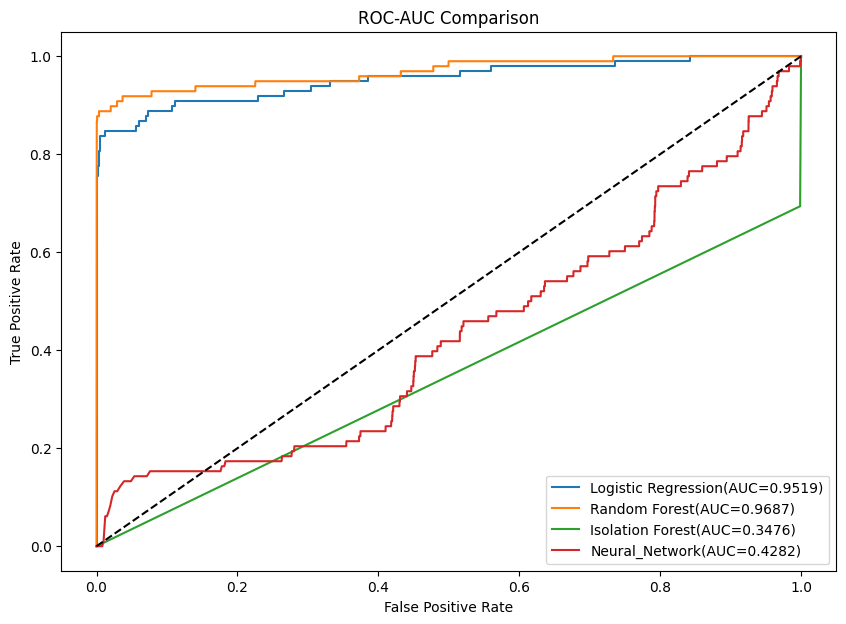

In [22]:
nn_probs=model_nn.predict(X_test).flatten()

models_dict['Neural_Network']=model_nn
plot_roc_curves(models_dict,X_test,y_test)

In [27]:
from tensorflow.keras.layers import BatchNormalization

model_nn=Sequential([
    tf.keras.layers.Input(shape=(X_train_smote.shape[1],)),

    Dense(64,activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32,activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(1,activation='sigmoid')
])

optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)
model_nn.compile(optimizer=optimizer,
                loss='binary_crossentropy',
                metrics=['accuracy',tf.keras.metrics.AUC(name='auc')])

history=model_nn.fit(
    X_train_smote,y_train_smote,
    validation_split=0.2,
    batch_size=1024,
    epochs=15,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
356/356 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5360 - auc: 0.5474 - loss: 0.7341 - val_accuracy: 0.5137 - val_auc: 0.5776 - val_loss: 0.7258
Epoch 2/15
356/356 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6833 - auc: 0.7638 - loss: 0.5572 - val_accuracy: 0.5012 - val_auc: 0.8651 - val_loss: 1.2752
Epoch 3/15
356/356 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8189 - auc: 0.9196 - loss: 0.3372 - val_accuracy: 0.5016 - val_auc: 0.9855 - val_loss: 0.5736
Epoch 4/15
356/356 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8285 - auc: 0.9346 - loss: 0.2951 - val_accuracy: 0.5849 - val_auc: 0.9834 - val_loss: 0.9901
Epoch 5/15
356/356 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8287 - auc: 0.9345 - loss: 0.2934 - val_accuracy: 0.9635 - val_auc: 0.9946 - val_loss: 0.0968
Epoch 6/15
356/356 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8287 - auc: 0.9371 - loss: 0.2798 - val_accuracy: 0.9700 - val_auc: 0.9961 - val_loss: 0.0874
Epoch 7/15
356/356 ━━━━━━━━━━━━━━━━━━━━ 

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


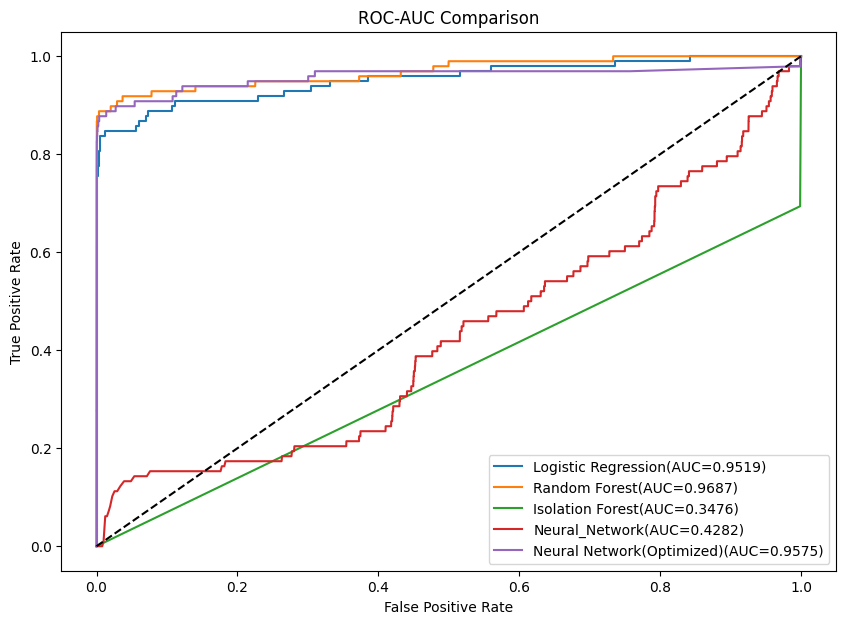

In [29]:
nn_probs=model_nn.predict(X_test).flatten()

models_dict['Neural Network(Optimized)']=model_nn

plot_roc_curves(models_dict,X_test,y_test)